In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def calculate_similarities(df, col1, col2):
    # Define the function to calculate Jaccard similarity
    def jaccard_similarity(tokens1, tokens2):
        set1 = set(tokens1)
        set2 = set(tokens2)
        return len(set1.intersection(set2)) / len(set1.union(set2))

    # Preprocess texts: Tokenization and stop words removal
    stop_words = set(stopwords.words('english'))
    
    def preprocess(text):
        return [word for word in word_tokenize(text.lower()) if word.isalnum() and word not in stop_words]
    
    df['processed_text1'] = df[col1].apply(preprocess)
    df['processed_text2'] = df[col2].apply(preprocess)
    
    # Combine all texts from col1 and col2 for a global vectorization
    all_texts = df['processed_text1'].apply(' '.join).tolist() + df['processed_text2'].apply(' '.join).tolist()
    
    # Fit the CountVectorizer on the entire corpus
    vectorizer = CountVectorizer().fit(all_texts)
    
    def cosine_similarity_row(text1, text2):
        vectors = vectorizer.transform([text1, text2]).toarray()
        return cosine_similarity(vectors)[0, 1]

    def process_row(row):
        jaccard_sim = jaccard_similarity(row['processed_text1'], row['processed_text2'])
        cosine_sim = cosine_similarity_row(' '.join(row['processed_text1']), ' '.join(row['processed_text2']))
        return pd.Series([jaccard_sim, cosine_sim])

    # Apply the process_row function to each row in the DataFrame
    similarities_df = df.apply(process_row, axis=1)
    similarities_df.columns = ['jaccard_similarity', 'cosine_similarity']
    
    # Drop the processed text columns (optional)
    df.drop(['processed_text1', 'processed_text2'], axis=1, inplace=True)
    
    return similarities_df

# Example usage:
# Assuming df is your DataFrame with columns 'text1' and 'text2'
# result_df = calculate_similarities(df, 'text1', 'text2')
# print(result_df.head())


In [3]:
import pandas as pd
generated_data = pd.read_csv('../generated_data_eficient_dist_improve.csv')

In [4]:
gen_data_similarities = calculate_similarities(generated_data, 'original_text', 'generated_text')

In [5]:
import matplotlib.pyplot as plt

def plot_similarity_distributions(result_df):
    """
    Plots the distribution of Jaccard and Cosine similarities.

    Parameters:
    - result_df: DataFrame containing 'jaccard_similarity' and 'cosine_similarity' columns.
    """
    plt.figure(figsize=(12, 6))

    # Plot distribution of Jaccard Similarity
    plt.subplot(1, 2, 1)
    plt.hist(result_df['jaccard_similarity'], bins=30, color='skyblue', edgecolor='black')
    plt.title('Distribution of Jaccard Similarity')
    plt.xlabel('Jaccard Similarity')
    plt.ylabel('Frequency')

    # Plot distribution of Cosine Similarity
    plt.subplot(1, 2, 2)
    plt.hist(result_df['cosine_similarity'], bins=30, color='salmon', edgecolor='black')
    plt.title('Distribution of Cosine Similarity')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')

    # Show the plots
    plt.tight_layout()
    plt.show()

# Example usage:
# Assuming result_df is the DataFrame containing the similarity columns
# plot_similarity_distributions(result_df)


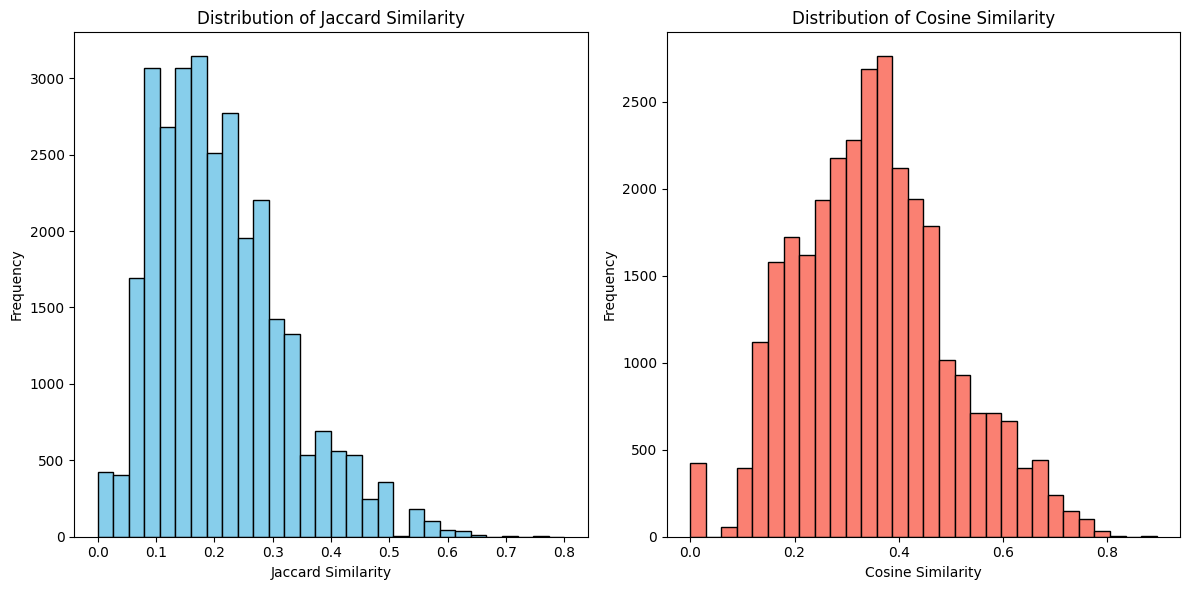

In [6]:
plot_similarity_distributions(gen_data_similarities)